In [59]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS
from sklearn.neighbors import KDTree
from sklearn.neighbors import NearestNeighbors

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from pyS3M import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from pyS3M import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import render
from pyS3M import postprocess as _postprocess
from pyS3M import FiducialDetection

FD = FiducialDetection.FiducialDetector()


import types

import pyS3M.DriftCorrectionFunctions as DCF
from pyS3M.LinkingFunctions import link_localisations


smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [60]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [61]:
image_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1"


In [82]:
localisation_files = H_F.file_search(image_folder, ".h5", "")

In [63]:
localisation_files

['/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1/Localisations.h5']

In [64]:
tif_files = H_F.file_search(image_folder, ".tif", "")

In [65]:
metadata_files = H_F.file_search(image_folder, "metadata", "")

In [66]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

In [72]:
loc_data = pd.read_hdf(localisation_files[0])

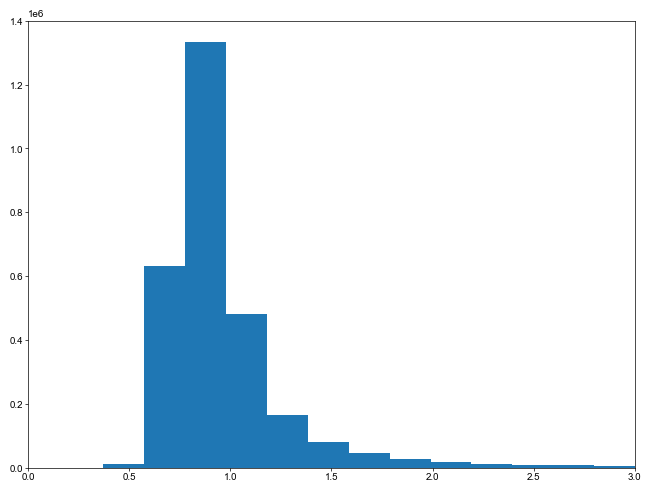

In [73]:
plt.hist(loc_data['chi_sqr'], 100);
plt.xlim([0, 3])
plt.show()

In [74]:
loc_data = loc_data[loc_data["xc_err"] < 50/69]
loc_data = loc_data[loc_data["yc_err"] < 50/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 50/69]
loc_data = loc_data[loc_data["s_y_err"] < 50/69]

loc_data = loc_data[(loc_data["s_x"] > 80/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 80/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.4]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[~((loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 50))]

loc_data = loc_data[loc_data["spot_background_std"] > 10]

#loc_data = loc_data[loc_data["photons"] < 100000]
#loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 2]

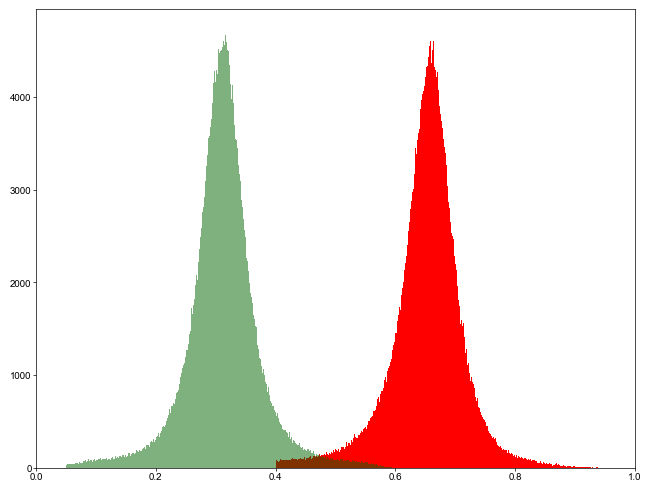

In [75]:
plt.hist(loc_data['A_R'], 1000, color='red');
plt.hist(loc_data['A_G'], 1000, alpha=0.5, color='darkgreen');
#plt.hist(loc_data['A_B'], 1000, alpha=0.5, color='lightblue');
plt.xlim([0, 1])
plt.show()

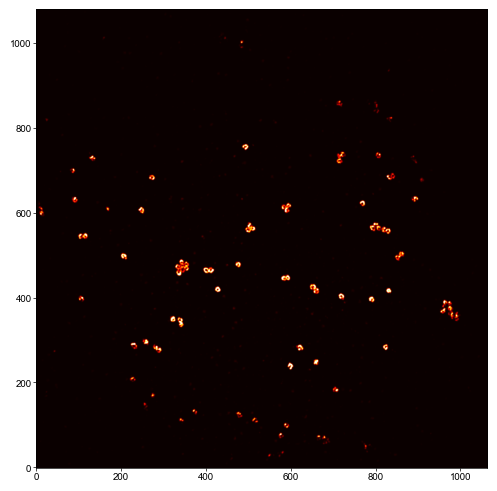

In [76]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

plt.imshow(image, origin='lower', cmap='hot', vmax=np.percentile(image, 99.9))

In [77]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=50,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

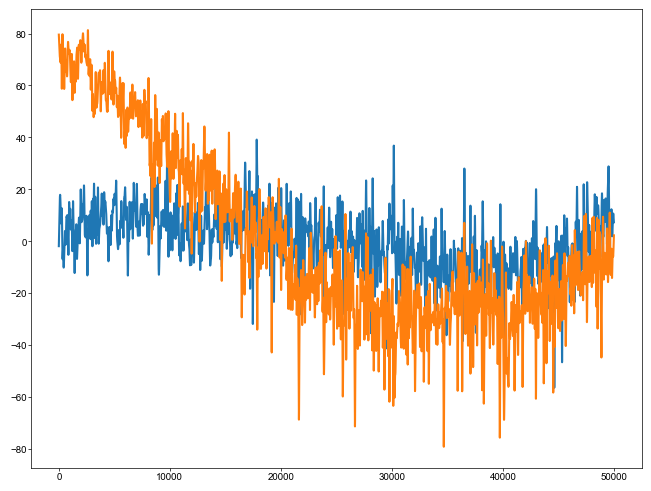

In [78]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [79]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

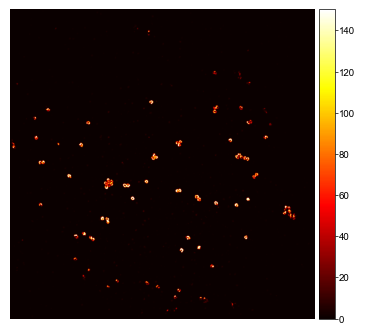

In [80]:
oversampling = 1

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling
        )[1]  # Take the rendered image

fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(axs, image, cmap='hot', vmax=np.percentile(image, 99.9), colorbar='off')

In [81]:
IO._write_h5_database(df=linked, filepath=localisation_files[0].split('.h5')[0]+'_Undrifted_Linked.h5', normalise_photons=False)

In [83]:
localisation_files

['/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1/Localisations.h5',
 '/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1/Localisations_Undrifted_Linked.h5']

In [84]:
linked = pd.read_hdf(localisation_files[1])

In [85]:
oversampling = 8
min_blur_width = 4*0.069
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

image = render.render(
            locs=linked.to_records(index=False),
            info=info,
            blur_method="smooth",
            oversampling=oversampling,
            min_blur_width=min_blur_width
        )[1]  # Take the rendered image

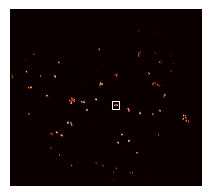

In [94]:
fig, axs = plotter.two_column_plot(height=2, width=2)

cut = image[:-800, :]
axs = plotter.image_plot(axs, cut, cmap='hot', vmax=np.percentile(image, 99.9), pixelsize=69/oversampling)[0]


import matplotlib.patches as patches

xval = 565
yval = 430
rect = patches.Rectangle(
    ((xval * oversampling), (yval * oversampling)),
    40 * oversampling,
    40 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "Image_SAureus_ZWO.svg"), dpi=600, format="svg")
plt.show()

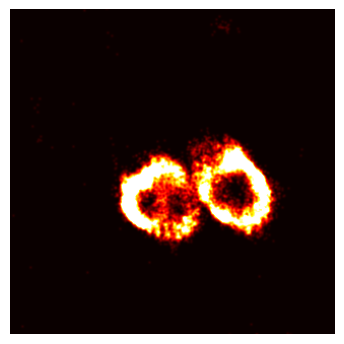

In [95]:
fig, axs = plotter.one_column_plot()

data = cut[
        int(yval * oversampling) : int(yval * oversampling) + int(40 * oversampling),
        int(xval) * oversampling : int(xval) * oversampling + int(40 * oversampling),
    ]

axs = plotter.image_plot(
    axs,
    image=data,
    vmin=np.percentile(cut, 1),
    vmax=np.percentile(cut, 99.9),
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
    cmap="hot",
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomin_ZWO.svg"), dpi=600, format="svg")
plt.show()

In [96]:
linked.columns

Index(['frame', 'xc', 'yc', 'xc_err', 'yc_err', 'photons', 'bg_B', 'bg_G',
       'bg_R', 'A_B', 'A_B_err', 'A_G', 'A_G_err', 'A_R', 'A_R_err', 's_x',
       's_x_err', 's_y', 's_y_err', 'chi_sqr', 'bg_B_err', 'bg_G_err',
       'bg_R_err', 'spot_matched_filter_response', 'spot_background',
       'spot_background_std', 'spot_mean_inner_intensity',
       'spot_fraction_above_threshold', 'spot_n_pixels_above_threshold',
       'spot_snr', 'background_photons', 'len', 'n', 'photon_rate'],
      dtype='object')

INFO:pyS3M.postprocess:Step 1/5: Rendering super-resolved image...
INFO:pyS3M.postprocess:Step 2/5: Applying li thresholding...
INFO:pyS3M.postprocess:Step 3/5: Detecting connected regions...
INFO:pyS3M.postprocess:Step 4/5: Filtering aggregates by size and localisation count...


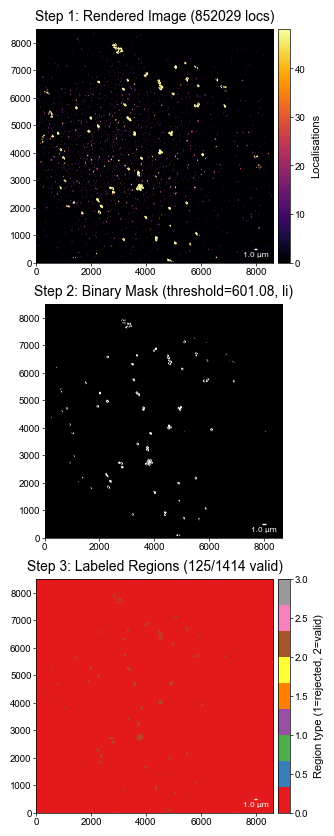

INFO:pyS3M.postprocess:Found 125 valid aggregates (from 1414 total regions)
INFO:pyS3M.postprocess:Step 5/5: Extracting localisations and computing statistics...


INFO:pyS3M.postprocess:✓ Complete! Extracted 745789 localisations in 125 aggregates


In [97]:
# Define parameters
MIN_AREA_NM2 = 100.0  # Minimum area threshold in nm² (50000 nm² = 0.05 µm²)
MIN_LOCS = 20      # Minimum localisations per cluster
PIXEL_SIZE_NM = 69.0  # Camera pixel size in nanometers
OVERSAMPLING = 8      # Super-resolution rendering oversampling


file = localisation_files[1]
# Run memory-efficient segmentation
# This uses image thresholding instead of DBSCAN - MUCH more memory efficient!
bacteria_locs, per_bacteria_stats = _postprocess.segment_locs_by_rendered_image(
    linked,
    width=width,
    height=height,
    oversampling=OVERSAMPLING,
    pixel_size_nm=PIXEL_SIZE_NM,
    min_area_nm2=MIN_AREA_NM2,
    min_localisations=MIN_LOCS,
    threshold_method='li',  # Li thresholding works well for bacterial imaging
    callback='console',
    blur_method='gaussian',
    verbose=True,
)

# Rename columns to match expected output format
bacteria_locs = bacteria_locs.rename(
    columns={'aggregate_id': 'cluster_id', 'aggregate_area_nm2': 'cluster_area_nm2'}
)
per_bacteria_stats = per_bacteria_stats.rename(
    columns={'aggregate_id': 'cluster_id'}
)

# Save results (same file names as before)
IO._write_h5_database(
    df=bacteria_locs,
    filepath=file.split('.h5')[0] + '_clusteredlocs.h5',
    append=False,
    normalise_photons=False
)

IO._write_h5_database(
    df=per_bacteria_stats,
    filepath=file.split('.h5')[0] + '_averagedoverclusters.h5',
    append=False,
    normalise_photons=False
)

In [98]:
analysis_files = H_F.file_search(image_folder, "_clusteredlocs.h5", "")
print(analysis_files)

['/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1/Localisations_Undrifted_Linked_clusteredlocs.h5']


In [99]:
import pyS3M.NileRedFunctions as NileRedFunctions
import pyS3M.SpectralFunctions as SpectralFunctions

# Initialize
nrf = NileRedFunctions.NileRed_Functions()

# Define optical setup
filters = [
  "semrock-ff01-650-200",
  "semrock-di03-r514-t1-25x36",
  "semrock-ff01-515-lp",
]

# Setup camera parameters
sf = SpectralFunctions.Spectral_Funcs()
R, G, B, wavelength = sf.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])

camera_params = {
  'pixel_QYs': pixel_QYs,
  'wavelength': wavelength,
}

analysis_files = H_F.file_search(image_folder, "_clusteredlocs.h5", "")

MIN_LOCS_ANALYSIS = 10      # Minimum localisations per wl fit

for file in analysis_files:
    # Fit wavelengths from HDF5 file
    # should now average and use average as initial guess
    df_with_wavelengths, grid_info = nrf.fit_wavelengths_pixelated(
      h5_path=file,
      filter_names=filters,
      camera_parameters=camera_params,
      output_path=file,
      min_localisations=MIN_LOCS_ANALYSIS,
      pixel_size_nm=50,
      aggregate_id_column='cluster_id',
    )

INFO:pyS3M.NileRedFunctions:
INFO:pyS3M.NileRedFunctions:Pixelated Nile Red Wavelength Fitting
INFO:pyS3M.NileRedFunctions:============================================================
INFO:pyS3M.NileRedFunctions:Input file: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/Brendan/20260624_SAureus_NR4A/FOV3/500pM_NR4A_60perc_515_515LP650200BP_Slide3_1/Localisations_Undrifted_Linked_clusteredlocs.h5
INFO:pyS3M.NileRedFunctions:Grid pixel size: 50 nm
INFO:pyS3M.NileRedFunctions:Min localisations per pixel: 10
INFO:pyS3M.NileRedFunctions:Wavelength bounds: 500.0-750.0 nm
INFO:pyS3M.NileRedFunctions:============================================================

INFO:pyS3M.NileRedFunctions:Loaded 745789 localisations
INFO:pyS3M.NileRedFunctions:Optical system configured with 3 filters
INFO:pyS3M.NileRedFunctions:Using photon counts for SNR-based error inflation
INFO:pyS3M.NileRedFunctions:
--- Fitting aggregate-level wavelengths ---
INFO:pyS3M.NileRedFunctions:Grouping by 'cluster_id'..

NameError: name 'self' is not defined

In [ ]:
df_with_wavelengths = pd.read_hdf(analysis_files[0])

In [ ]:
oversampling=8

n_locs, image_FOV, image_FOV_colour = render.render(
    locs=df_with_wavelengths.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (np.max(df_with_wavelengths['yc']), np.max(df_with_wavelengths['xc']))),
    blur_method="gaussian_colour",
    cparam='wl_pixel',
    c_min=np.percentile(df_with_wavelengths['wl_pixel'], 5),
    c_max=np.percentile(df_with_wavelengths['wl_pixel'], 95),
)


In [ ]:
from matplotlib import colors as mcolors

In [ ]:
from copy import copy

In [ ]:
image_total = copy(image_FOV)
vmax = np.percentile(image_total, 99.5)  # ignore empty pixels
vmin = np.percentile(image_total, 1)                                                                                                                                                                                                                                                  

new_brightness = np.clip((image_total - vmin) / (vmax - vmin), 0, 1)                                                                                                                                                                                           
                                                        
hsv = mcolors.rgb_to_hsv(image_FOV_colour)                                                                                                                                                                                                                         
hsv[..., 2] = new_brightness                              
image_adjusted = mcolors.hsv_to_rgb(hsv)

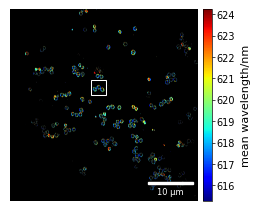

In [17]:
fig, axs = plotter.two_column_plot(height=2, width=2.25)

cut = image_adjusted[:-800, :]
axs = plotter.colour_image_plot(axs, cut, cbar="on", cbarlabel=r'mean wavelength/nm', cmap="jet",
                            c_min=np.percentile(df_with_wavelengths['wl_pixel'], 5),
                            c_max=np.percentile(df_with_wavelengths['wl_pixel'], 95),
                            pixelsize=69/oversampling)

import matplotlib.patches as patches

rect = patches.Rectangle(
    ((260 * oversampling), (340 * oversampling)),
    50 * oversampling,
    50 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)


folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "Image_SAureus_Wavelength.svg"), dpi=600, format="svg")
plt.show()

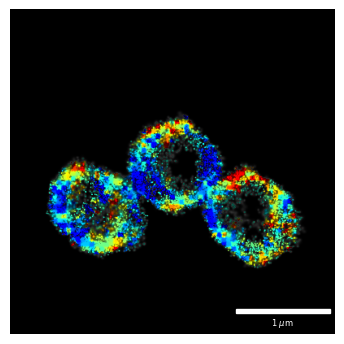

In [18]:
fig, axs = plotter.one_column_plot()

cut = image_adjusted[500:, 500:, :]
data = cut[
        int(340 * oversampling) : int(340 * oversampling) + int(50 * oversampling),
        int(260) * oversampling : int(260) * oversampling + int(50 * oversampling),
        :
    ]

axs = plotter.colour_image_plot(
    axs=axs,
    data=data,
    cbar='off',
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomin_Colour.svg"), dpi=600, format="svg")
plt.show()

In [19]:
def get_region_localisations(df, rectangles):
    """
    Filter localisations within each rectangle.

    Parameters
    ----------
    df : DataFrame
        Localisation table with 'xc', 'yc' in camera pixels.
    rectangles : list of dict
        Each dict: x0, y0, w, h in camera pixels; color and label are optional.

    Returns
    -------
    list of DataFrame, one per rectangle (same order as input).
    """
    regions = []
    for rect in rectangles:
        mask = (
            (df['xc'] >= rect['x0'])              &
            (df['xc'] <  rect['x0'] + rect['w']) &
            (df['yc'] >= rect['y0'])              &
            (df['yc'] <  rect['y0'] + rect['h'])
        )
        regions.append(df[mask].copy())
    return regions


In [4]:
671 / (4*5)

33.55

In [52]:
# Rectangles in absolute camera pixels (matching xc/yc in df_with_wavelengths).
# The zoom-in spans x ∈ [322.5, 372.5] and y ∈ [402.5, 452.5] camera pixels.
rects = [
    dict(x0=351, y0=425, w=4, h=5, color='#4363d8', label='Region A'),
    dict(x0=355, y0=424, w=4, h=5, color='#e6194b', label='Region B'),
]

region_A, region_B = get_region_localisations(df_with_wavelengths, rects)
print(f"Region A: {len(region_A)} localisations")
print(f"Region B: {len(region_B)} localisations")


Region A: 750 localisations
Region B: 671 localisations


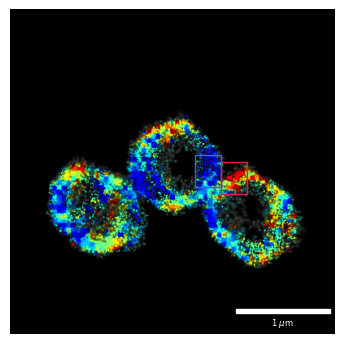

In [77]:
import matplotlib.patches as patches

fig, axs = plotter.one_column_plot()

cut = image_adjusted[500:, 500:, :]
data = cut[
    int(340 * oversampling) : int(340 * oversampling) + int(50 * oversampling),
    int(260) * oversampling : int(260) * oversampling + int(50 * oversampling),
    :
]

axs = plotter.colour_image_plot(
    axs=axs,
    data=data,
    cbar='off',
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
)

# Origin of the zoom-in region in absolute camera pixels.
# cut offset = 500 SR px / oversampling; zoom origin within cut = (260, 340) cam px.
zoom_x0_cam = 500 / oversampling + 260   # = 322.5
zoom_y0_cam = 500 / oversampling + 340   # = 402.5

zoomed_images = {}
for i, r in enumerate(rects):
    # Convert from absolute camera pixels → zoom-in SR pixel coordinates
    x_zoom = (r['x0'] - zoom_x0_cam) * oversampling
    y_zoom = (r['y0'] - zoom_y0_cam) * oversampling
    w_zoom = r['w'] * oversampling
    h_zoom = r['h'] * oversampling
    axs.add_patch(patches.Rectangle(
        (x_zoom, y_zoom), w_zoom, h_zoom,
        linewidth=1, edgecolor=r['color'], facecolor='none',
    ))
    zoomed_images[i] = data[int(y_zoom):int(y_zoom+h_zoom), int(x_zoom):int(x_zoom+w_zoom)]

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomin_Colour_Rects.svg"), dpi=600, format="svg")
plt.show()


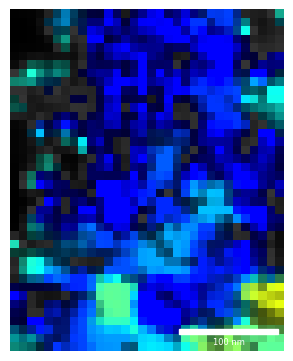

In [82]:
fig, axs = plotter.one_column_plot()


axs = plotter.colour_image_plot(
    axs=axs,
    data=zoomed_images[0],
    cbar='off',
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=100,
    scalebarlabel=r"100 nm",
)
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomed_Area_1.svg"), dpi=600, format="svg")
plt.show()



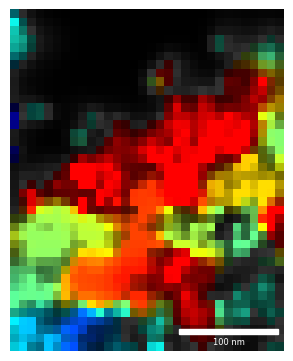

In [83]:
fig, axs = plotter.one_column_plot()


axs = plotter.colour_image_plot(
    axs=axs,
    data=zoomed_images[1],
    cbar='off',
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=100,
    scalebarlabel=r"100 nm",
)
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Zoomed_Area_2.svg"), dpi=600, format="svg")
plt.show()


In [94]:
print(len(region_B))

671


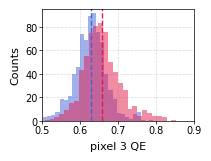

In [92]:
fig, axs = plotter.one_column_plot(width=2, height=1.5)

axs = plotter.histogram_plot(axs, region_A['A_R'], np.histogram_bin_edges(region_A['A_R'], 'fd'),
                             density=False,
                            histcolor='#4363d8', alpha=0.5);
axs = plotter.histogram_plot(axs, region_B['A_R'], np.histogram_bin_edges(region_B['A_R'], 'fd'),
                             density=False,
                            histcolor='#e6194b', alpha=0.5, xaxislabel='pixel 3 QE');

axs.vlines(ymin=0, ymax=100, x=np.mean(region_A['A_R']), color='#4363d8', ls='--', lw=1)
axs.vlines(ymin=0, ymax=100, x=np.mean(region_B['A_R']), color='#e6194b', ls='--', lw=1)

#plt.legend(loc='best', fontsize=6)
axs.set_ylim([0, 95])
plt.xlim([0.5, 0.9])
folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Histogram.svg"), dpi=600, format="svg")
plt.show()

In [31]:
averaged = df_with_wavelengths.groupby('pixel_ix', as_index=False).agg(                                                                                                                                                                                                         
      xc       = ('xc',      'mean'),                                                                                                                                                                                                                          
      yc       = ('yc',      'mean'),                                                                                                                                                                                                                            
      A_R      = ('A_R',     'mean'),                                                                                                                                                                                                                            
      A_G      = ('A_G',     'mean'),                                                                                                                                                                                                                            
      A_B      = ('A_B',     'mean'),                                                                                                                                                                                                                            
      photons  = ('photons', 'sum'),  
      wl_pixel = ('wl_pixel', 'mean'),
      n_locs   = ('frame',   'count'),   # number of localisations per pixel                                                                                                                                                                                     
  )

In [9]:
averaged['log_photons'] = np.log10(averaged['photons'])


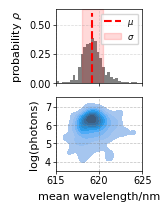

In [13]:
import seaborn as sns

fig, axs = plotter.one_column_plot(width=1.5, height=2, npanels=2, ratios=[1,1])

axs[0] = plotter.histogram_plot(axs[0], averaged['wl_pixel'], bins=np.histogram_bin_edges(averaged['wl_pixel'], 'fd'),
                               xaxislabel='')
mean=np.mean(averaged['wl_pixel'])
axs[0].vlines(x=mean, ymin=0, ymax=0.6, ls='--', color='red', label=r'$\mu$')

std=np.std(averaged['wl_pixel'])
axs[0].axvspan(mean - std, mean + std, alpha=0.15, color='red', label=r'$\sigma$')

axs[0].set_ylabel(r'probability $\rho$')
axs[0].set_xticklabels([])
axs[0].legend(fontsize=6)
axs[1].grid(True, lw=0.5, alpha=0.5, ls='--', color='grey')

sns.kdeplot(data=averaged, x="wl_pixel", y="log_photons", ax=axs[1], fill=True)
axs[1].set_xlabel('mean wavelength/nm')
axs[1].set_ylabel('log(photons)')
axs[1].set_ylim([3.5, 7.5])
axs[1].set_yticks([4, 5, 6, 7])
axs[1].set_xlim([615, 625])
axs[0].set_xlim([615, 625])

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "SAureus_Analysis_Wavelength.svg"), dpi=600, format="svg")
plt.show()

In [48]:
np.mean(averaged['wl_pixel'])

619.24994482625755

In [49]:
np.nanstd(averaged['wl_pixel'])

1.2577634767109238

In [ ]:
from pyS3M.FRCFunctions import fire


In [ ]:
# --- parameters ---
pixel_size_nm = 69      # nm per camera pixel
zoom          = 8      # SR pixels per camera pixel → 6.9 nm SR pixels

# linked_fremoved, width, height already defined in the notebook

# Shift localisations to start from (0,0) within their bounding box                                                                                                                                                                                            
red_xy = linked[['xc', 'yc']].to_numpy()                                                                                                                                                                                                                    
                                                                                                                                                                                                                                                             
x_min, y_min = red_xy[:, 0].min(), red_xy[:, 1].min()     
red_xy_shifted = red_xy.copy()                                                                                                                                                                                                                                 
red_xy_shifted[:, 0] -= x_min                                                                                                                                                                                                                                  
red_xy_shifted[:, 1] -= y_min
                                                                                                                                                                                                                                                             
nx_eff_red = int(red_xy[:, 0].max() - x_min) + 1                                                                                                                                                                                                                   
ny_eff_red = int(red_xy[:, 1].max() - y_min) + 1                                                                                                                                                                                                                   
print(f"Effective field: {nx_eff_red} × {ny_eff_red} px  ({nx_eff_red*69:.0f} × {ny_eff_red*69:.0f} nm)")                                                                                                                                                                      
                                                                                                                                                                                                                                                             
resolution_nm_655, frc_mean_655, res_hi_nm_655, res_lo_nm_655 = fire(                                                                                                                                                                                          
  positions     = red_xy_shifted,                                                                                                                                                                                                                            
  nx            = nx_eff_red,                                                                                                                                                                                                                                    
  ny            = ny_eff_red,                                                                                                                                                                                                                                    
  zoom          = zoom,
  n_blocks      = 50,                                                                                                                                                                                                                                        
  pixel_size_nm = pixel_size_nm,                                                                                                                                                                                                                             
)                                                                                                                                                                                                                                                              
print(f"FIRE resolution: {resolution_nm_655:.1f} nm")                                                                                                                                                                                                          

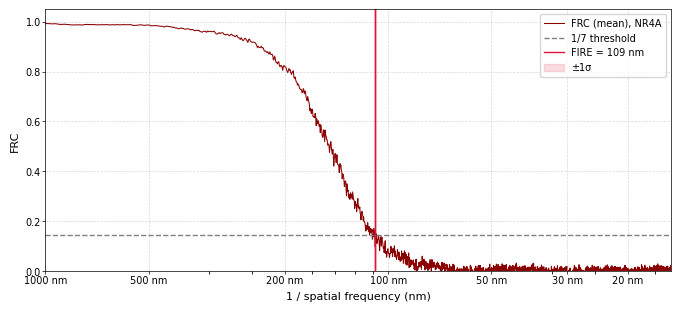

In [49]:
fig, ax = plotter.two_column_plot()

sz_red       = max(nx_eff_red, ny_eff_red) * zoom

sr_px_nm = pixel_size_nm / zoom        # nm per SR pixel

k_red   = np.arange(len(frc_mean_655))
q_red   = k_red / sz_red                           # cycles per SR pixel
q_nm_red = q_red / sr_px_nm                   # cycles per nm  (= 1 / d_nm)

# keep only below Nyquist
mask_red = (q_red > 0) & (q_red < 0.6)

# 1/7 crossing in cycles/nm
q_cross_655 = 1.0 / resolution_nm_655         # cycles per nm at the FIRE value
q_hi_655    = 1.0 / res_hi_nm_655
q_lo_655    = 1.0 / res_lo_nm_655

ax = plotter.line_plot(ax, q_nm_red[mask_red], frc_mean_655[mask_red], label='FRC (mean), NR4A', color='darkred')

ax.axhline(1/7, color='gray', ls='--', lw=1, label='1/7 threshold')
ax.axvline(q_cross_655, color='crimson', ls='-', lw=1,
           label=f'FIRE = {resolution_nm_655:.0f} nm')
ax.axvspan(q_lo_655, q_hi_655, alpha=0.15, color='crimson', label='±1σ')

ax.set_xlabel(r'1 / spatial frequency (nm)', fontsize=8)
ax.set_ylabel('FRC', fontsize=8)
ax.set_ylim([0, 1.05])
ax.set_xscale('log')

tick_nm = [1000, 500, 200, 100, 50, 30, 20]          # nm values to label
ax.set_xticks([1/d for d in tick_nm])

ax.set_xticklabels([f'{d} nm' for d in tick_nm])
ax.set_xlim(1/1000, 1/15)
ax.legend(fontsize=7)

folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Talks'
plt.savefig(os.path.join(folder, "FRC_SAureus.svg"), dpi=600, format="svg")
